## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

In [16]:
import tensorflow as tf
import keras

import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

In [8]:
# Shapes of training & test data set
print("Samples in Training Set: {count}".format(count=x_train.size))
print("Samples in Test Set: {count}".format(count=x_test.size))

Samples in Training Set: 47040000
Samples in Test Set: 7840000


### Find dimensions of an image in the dataset

In [13]:
print("Dimensions of Image in dataset: {size1} X {size2} ".format(size1=x_train.shape[1],size2=x_train.shape[2]))

Dimensions of Image in dataset: 28 X 28 


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [17]:
#Encoding the output class label (One-Hot Encoding)
train_Y=np_utils.to_categorical(y_train)
test_Y=np_utils.to_categorical(y_test)

In [25]:
train_Y[0:2]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

### Normalize both the train and test image data from 0-255 to 0-1

In [20]:
# normalize inputs from 0-255 to 0-1
x_train = x_train / 255
x_test = x_test / 255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [21]:
# Reshaping the array to 4-dims so that it can work with the Keras API
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

In [22]:
# Making sure that the values are float so that we can get decimal points after division
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

### Import the necessary layers from keras to build the model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.layers import Conv2D,MaxPooling2D

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [30]:
model = tf.keras.models.Sequential()

# 2 Conv layers having 32 3x3 filters in both convolutions with relu activations
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
# flatten before passing the feature map
model.add(tf.keras.layers.Flatten())
# 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with relu and softmax activations respectively
model.add(tf.keras.layers.Dense(128, activation='relu'))
#Output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [31]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:

# set early stopping with patience=5  
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Train the model with no.of epochs=10
model.fit(x_train,train_Y,      
          validation_data=(x_test,test_Y),
          epochs=10,
           callbacks=[callback])

W0818 14:40:36.191761  8776 deprecation.py:323] From C:\Users\Suchi\Anaconda3\lib\site-packages\tensorflow\python\ops\math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 91s 2ms/sample - loss: 0.7398 - accuracy: 0.7269 - val_loss: 0.5768 - val_accuracy: 0.7912
Epoch 2/10
60000/60000 [==============================] - 94s 2ms/sample - loss: 0.5005 - accuracy: 0.8155 - val_loss: 0.5050 - val_accuracy: 0.8127
Epoch 3/10
60000/60000 [==============================] - 96s 2ms/sample - loss: 0.4508 - accuracy: 0.8382 - val_loss: 0.4610 - val_accuracy: 0.8280
Epoch 4/10
60000/60000 [==============================] - 91s 2ms/sample - loss: 0.4214 - accuracy: 0.8478 - val_loss: 0.4324 - val_accuracy: 0.8409
Epoch 5/10
60000/60000 [==============================] - 92s 2ms/sample - loss: 0.3980 - accuracy: 0.8563 - val_loss: 0.4226 - val_accuracy: 0.8493
Epoch 6/10
60000/60000 [==============================] - 93s 2ms/sample - loss: 0.3826 - accuracy: 0.8610 - val_loss: 0.4279 - val_accuracy: 0.8456
Epoch 7/10
60000/60000 [==============================] 

In [33]:
score = model.evaluate(x_test, test_Y)
print('\n', 'Test accuracy for Model:', score[1]*100)

10000/10000 [==============================] - 2s 240us/sample - loss: 0.3931 - accuracy: 0.8617

 Test accuracy for Model : 86.16999983787537


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [34]:
model_2 = tf.keras.models.Sequential()

# 2 Conv layers having 32 3x3 filters in both convolutions with relu activations
model_2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))

# add max pooling layer of filter size 2x2
model_2.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
# add dropout layer with p=0.25 after the 2 conv layers
model.add(tf.keras.layers.Dropout(0.25))

# flatten before passing the feature map
model_2.add(tf.keras.layers.Flatten())
# 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with relu and softmax activations respectively
model_2.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model_2.add(tf.keras.layers.Dense(10, activation='softmax'))

In [35]:
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [36]:
# set early stopping with patience=5  
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Train the model with no.of epochs=10
model_2.fit(x_train,train_Y,      
          validation_data=(x_test,test_Y),
          epochs=10,
           callbacks=[callback])

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 70s 1ms/sample - loss: 0.7330 - accuracy: 0.7300 - val_loss: 0.5917 - val_accuracy: 0.7790
Epoch 2/10
60000/60000 [==============================] - 73s 1ms/sample - loss: 0.5225 - accuracy: 0.8080 - val_loss: 0.5450 - val_accuracy: 0.8050
Epoch 3/10
60000/60000 [==============================] - 69s 1ms/sample - loss: 0.4778 - accuracy: 0.8255 - val_loss: 0.4997 - val_accuracy: 0.8175
Epoch 4/10
60000/60000 [==============================] - 69s 1ms/sample - loss: 0.4448 - accuracy: 0.8386 - val_loss: 0.4510 - val_accuracy: 0.8400
Epoch 5/10
60000/60000 [==============================] - 72s 1ms/sample - loss: 0.4195 - accuracy: 0.8490 - val_loss: 0.4497 - val_accuracy: 0.8329
Epoch 6/10
60000/60000 [==============================] - 71s 1ms/sample - loss: 0.3977 - accuracy: 0.8565 - val_loss: 0.4233 - val_accuracy: 0.8474
Epoch 7/10
60000/60000 [==============================] 

In [37]:
score = model_2.evaluate(x_test, test_Y)
print('\n', 'Test accuracy for Model :', score[1]*100)

10000/10000 [==============================] - 2s 197us/sample - loss: 0.3409 - accuracy: 0.8791

 Test accuracy for Model : 87.91000247001648


### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [52]:
img_generator = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=15,
                                                                   width_shift_range=0.2,
                                                                   height_shift_range=0.1,
                                                                   horizontal_flip=True,
                                                                   shear_range=0.01)

In [53]:
img_generator.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

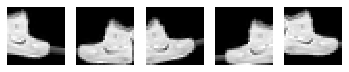

In [54]:
from matplotlib import pyplot as plt
gen = img_generator.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [55]:
# create the train and validation genarator using ImageDataGenerator
# train data generator with augmented data
train_generator = img_generator.flow(x_train, train_Y, batch_size=64)
# test data without augmentation
valid_generator = tf.keras.preprocessing.image.ImageDataGenerator().flow(x_test, test_Y, batch_size=64)

In [57]:
STEP_SIZE_TRAIN=train_generator.n//train_generator.batch_size
STEP_SIZE_VALID=valid_generator.n//valid_generator.batch_size

model_2.fit_generator(generator=train_generator,
                    steps_per_epoch=STEP_SIZE_TRAIN,
                    validation_data=valid_generator,
                    validation_steps=STEP_SIZE_VALID,
                    epochs=10)

Epoch 1/10
937/937 [==============================] - 64s 69ms/step - loss: 0.9023 - accuracy: 0.6715 - val_loss: 0.4861 - val_accuracy: 0.8303
Epoch 2/10
937/937 [==============================] - 65s 69ms/step - loss: 0.6802 - accuracy: 0.7430 - val_loss: 0.4918 - val_accuracy: 0.8231
Epoch 3/10
937/937 [==============================] - 68s 72ms/step - loss: 0.6331 - accuracy: 0.7602 - val_loss: 0.4827 - val_accuracy: 0.8231
Epoch 4/10
937/937 [==============================] - 68s 73ms/step - loss: 0.6045 - accuracy: 0.7712 - val_loss: 0.4674 - val_accuracy: 0.8307
Epoch 5/10
937/937 [==============================] - 69s 74ms/step - loss: 0.5815 - accuracy: 0.7815 - val_loss: 0.4604 - val_accuracy: 0.8331
Epoch 6/10
937/937 [==============================] - 68s 72ms/step - loss: 0.5618 - accuracy: 0.7868 - val_loss: 0.4465 - val_accuracy: 0.8398
Epoch 7/10
937/937 [==============================] - 69s 74ms/step - loss: 0.5427 - accuracy: 0.7954 - val_loss: 0.4409 - val_accuracy:

###  Report the final train and validation accuracy

In [58]:
score = model_2.evaluate(x_train, train_Y)
print('\n', 'Train accuracy for Model :', score[1]*100)

60000/60000 [==============================] - 12s 206us/sample - loss: 0.3922 - accuracy: 0.8562

 Train accuracy for Model : 85.61999797821045


In [59]:
score = model_2.evaluate(x_test, test_Y)
print('\n', 'Validation accuracy for Model :', score[1]*100)

10000/10000 [==============================] - 2s 194us/sample - loss: 0.4323 - accuracy: 0.8436

 Validation accuracy for Model : 84.35999751091003


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [62]:
from keras_preprocessing.image import ImageDataGenerator

### **Load CIFAR10 dataset**

In [63]:
from keras.datasets import cifar10

In [64]:
(cx_train, cy_train), (cx_test, cy_test) = cifar10.load_data()

170500096/170498071 [==============================] - 16s 0us/step


In [65]:
# Shapes of training & test data set
print("Samples in Training Set: {count}".format(count=cx_train.size))
print("Samples in Test Set: {count}".format(count=cx_test.size))

Samples in Training Set: 153600000
Samples in Test Set: 30720000


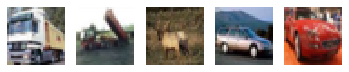

In [72]:
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(cx_train[i,:,:])
    plt.plot()
plt.show()

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [73]:
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=15,
                                                                   width_shift_range=0.2,
                                                                   height_shift_range=0.1,
                                                                   horizontal_flip=True)

### **Prepare/fit the generator.**

In [75]:
data_gen.fit(cx_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

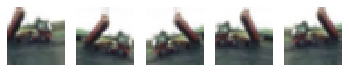

In [81]:
gen = data_gen.flow(cx_train[2:3], batch_size=1)

for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().astype(np.uint8).squeeze())
    plt.plot()
plt.show()